# 🎓 ICA Image Demixing Exercise

Welcome to the **Independent Component Analysis (ICA)** image demixing exercise! 

In this exercise, we will walk through the process of:
1. Generating a set of visually distinct, non-Gaussian source images.
2. Using the `mixer` package's `ImageMixer` class to create linear mixtures of these sources with optional noise and RGB channel preservation.
3. Saving the mixed images and metadata (acting as the instructor creating the assignment).
4. Loading the mixed images and applying the **FastICA** algorithm from `scikit-learn` to separate and reconstruct the original sources (acting as the student solving the assignment).

## 🛠️ Step 0: Imports and Environment Setup

First, let's import the necessary libraries. We'll use `numpy`, `matplotlib` for plotting, `Pillow` for image drawing/manipulation, `ImageMixer` from our custom package, and `FastICA` from `scikit-learn`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from mixer import ImageMixer
from sklearn.decomposition import FastICA

## 🎨 Step 1: Create the Source Images (Ground Truth)

For ICA to work well, the source signals must be **mutually independent** and **non-Gaussian** (since Gaussian signals cannot be separated by ICA). 

Let's generate 3 distinct RGB source images:
1. **Source 1**: A 2D sine/cosine wave pattern (smooth continuous gradient).
2. **Source 2**: A color checkerboard pattern (high-frequency edges).
3. **Source 3**: A set of basic geometric shapes (a yellow circle and a magenta triangle).

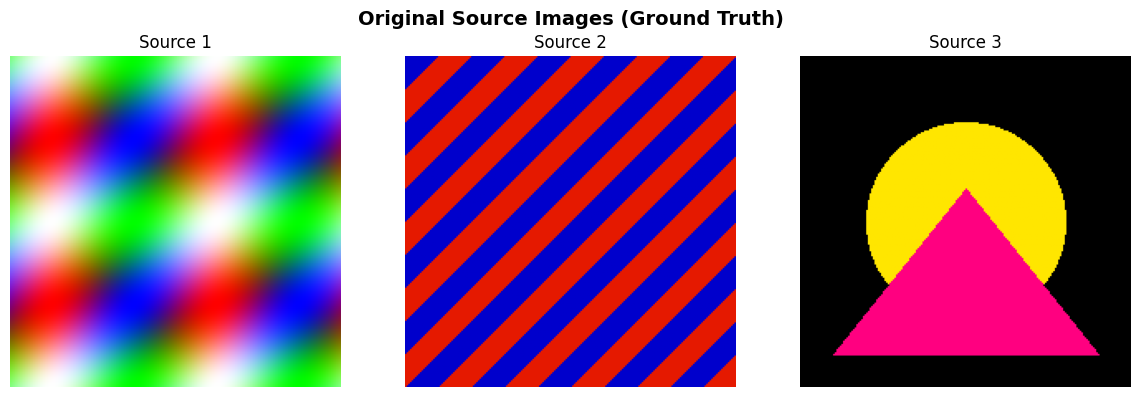

In [2]:
# Define the resolution for the exercise
size = (200, 200)

# 1. Source 1: 2D Sine wave gradient
x = np.linspace(0, 4 * np.pi, size[0])
y = np.linspace(0, 4 * np.pi, size[1])
X, Y = np.meshgrid(x, y)
src1 = np.zeros((size[0], size[1], 3))
src1[:, :, 0] = (np.sin(X) + 1.0) / 2.0            # Red channel
src1[:, :, 1] = (np.cos(Y) + 1.0) / 2.0            # Green channel
src1[:, :, 2] = (np.sin(X + Y) + 1.0) / 2.0        # Blue channel

# 2. Source 2: Checkerboard pattern
src2 = np.zeros((size[0], size[1], 3))
chk = (np.indices(size).sum(axis=0) // 20) % 2
src2[:, :, 0] = chk * 0.9                          # Red
src2[:, :, 1] = chk * 0.1                          # Green
src2[:, :, 2] = (1 - chk) * 0.8                    # Blue

# 3. Source 3: Geometric shapes
src3_img = Image.new("RGB", size, "black")
draw = ImageDraw.Draw(src3_img)
draw.ellipse([40, 40, 160, 160], fill=(255, 230, 0))            # Yellow circle
draw.polygon([(20, 180), (100, 80), (180, 180)], fill=(255, 0, 128)) # Magenta triangle
src3 = np.array(src3_img) / 255.0

sources = [src1, src2, src3]

# Plot the original source images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, src in enumerate(sources):
    axes[idx].imshow(src)
    axes[idx].set_title(f"Source {idx + 1}")
    axes[idx].axis("off")
plt.suptitle("Original Source Images (Ground Truth)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 🧪 Step 2: Mix the Images (Instructor Setup)

Now we'll act as the instructor creating the assignment. We will mix the source images using `ImageMixer`. We will:
- Enable RGB channel mixing (`mix_by_channel=True`), meaning the same mixing matrix $A$ is applied to each of the R, G, and B channels to preserve color information.
- Add a small amount of Gaussian noise (`add_noise=True`, `noise_level=0.02`) to make the reconstruction realistic.
- Set a random `seed` for reproducibility.
- Save the mixed images to a directory (`exercise_data/`) and export the metadata (which contains the mixing matrix $A$ for verification).

2026-06-04 16:46:38.574 | DEBUG    | mixer.image_mixer:mix:172 - Resolved mixing size to: (200, 200)


2026-06-04 16:46:38.578 | DEBUG    | mixer.image_mixer:_generate_well_conditioned_matrix:124 - Generated mixing matrix of shape (3, 3) with condition number 3.6462


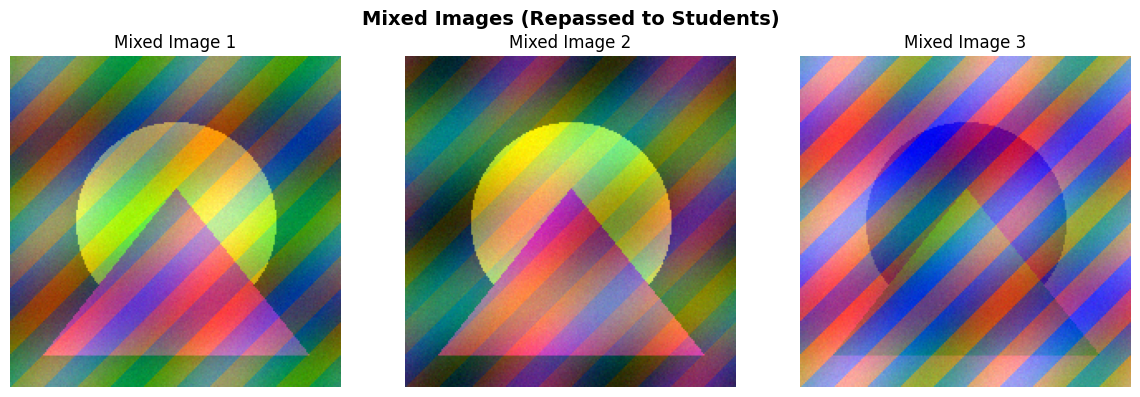

2026-06-04 16:46:38.679 | INFO     | mixer.image_mixer:save_mixed_images:282 - Saved 3 mixed images to exercise_data


2026-06-04 16:46:38.680 | INFO     | mixer.image_mixer:save_metadata:327 - Saved mixture metadata to exercise_data/metadata.json


Created mixed files in 'exercise_data/'.
The generated mixing matrix A is:
[[ 1.27395605 -0.93887844  1.35859792]
 [-1.19736803 -0.59417735  1.47562235]
 [ 1.2611397   1.28606431 -0.62811363]]


In [3]:
# Initialize the ImageMixer
mixer = ImageMixer(size=size, mix_by_channel=True, add_noise=True, noise_level=0.02, seed=42)

# Mix the source images
mixed_images = mixer.mix(sources)

# Display the mixed images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, mixed_img in enumerate(mixed_images):
    axes[idx].imshow(mixed_img)
    axes[idx].set_title(f"Mixed Image {idx + 1}")
    axes[idx].axis("off")
plt.suptitle("Mixed Images (Repassed to Students)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Save the exercise files
output_dir = "exercise_data"
mixer.save_mixed_images(output_dir, prefix="mixed")
mixer.save_metadata(os.path.join(output_dir, "metadata.json"))
print(f"Created mixed files in '{output_dir}/'.")
print("The generated mixing matrix A is:")
print(mixer.mixing_matrix_)

## 🕵️‍♂️ Step 3: Solve the Exercise (Student Perspective)

Now we switch to the student's perspective. The student receives the mixed images and needs to recover the original source images.

### Mathematical Insight:
Since the mixing was done by channel, we have:
$$X_c = A S_c$$
for each channel $c \in \{\text{Red}, \text{Green}, \text{Blue}\}$, where:
- $S_c$ is the $N \times P$ source matrix for channel $c$ ($N$ is the number of sources, $P$ is the number of pixels $H \times W$).
- $A$ is the $M \times N$ mixing matrix (identical for all channels).
- $X_c$ is the $M \times P$ mixed image matrix for channel $c$.

Because the mixing matrix $A$ is identical for all three channels, we can convert the mixed images to grayscale and run FastICA on the grayscale mixtures to find the **unmixing matrix** $W \approx A^{-1}$. Once we have $W$, we can apply it to each RGB channel independently to recover the full-color sources!

In [4]:
# 1. Load the mixed images
mixed_loaded = []
for idx in range(3):
    img_path = f"exercise_data/mixed_{idx}.png"
    img = Image.open(img_path)
    mixed_loaded.append(np.array(img, dtype=np.float32) / 255.0)

# 2. Convert mixtures to grayscale to find the unmixing matrix W
mixed_gray = []
for img in mixed_loaded:
    # Standard luminance weights
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    mixed_gray.append(gray.ravel())

# Stack to shape (M, H*W)
X_gray = np.vstack(mixed_gray)

# 3. Run FastICA on the grayscale mixtures
# Note: FastICA expects shape (n_samples, n_features) where columns are mixtures.
# So we pass X_gray.T (shape: H*W x M)
ica = FastICA(n_components=3, random_state=42)
sources_recovered_gray = ica.fit_transform(X_gray.T) # shape: (H*W, N)

# Extract the estimated unmixing matrix W (from ica.components_)
W = ica.components_ # shape: (N, M)
print("Estimated unmixing matrix W shape:", W.shape)

Estimated unmixing matrix W shape: (3, 3)


### Reconstructing the Color Sources

Now we apply $W$ to each RGB channel to obtain the reconstructed sources. Since ICA has scaling and sign/inversion ambiguity, we'll normalize the reconstructed channels to the $[0, 1]$ range.

In [5]:
reconstructed_sources = []
for j in range(3): # For each recovered source
    rec_img = np.zeros((size[0], size[1], 3))
    for c in range(3): # For each color channel
        # Stack mixed channel c for all mixtures: shape (M, H*W)
        X_c = np.vstack([img[:, :, c].ravel() for img in mixed_loaded])
        # Recover source channel c using the unmixing matrix W
        S_rec_c = W @ X_c # shape: (N, H*W)
        
        # Reshape channel back to 2D
        chan = S_rec_c[j].reshape(size)
        
        # Normalize to [0, 1] range to handle scaling/inversion ambiguity
        c_min, c_max = chan.min(), chan.max()
        if c_max > c_min:
            chan = (chan - c_min) / (c_max - c_min)
        
        rec_img[:, :, c] = chan
    reconstructed_sources.append(rec_img)

### Resolving Permutation Ambiguity

ICA cannot determine the original order of the sources (permutation ambiguity). Let's write a small snippet to match each recovered source with its best original source by calculating the correlation, so we can plot them side-by-side!

In [6]:
# Find best match between recovered and original sources
matched_reconstructed = [None] * 3
for i, rec in enumerate(reconstructed_sources):
    best_corr = -1
    best_match = 0
    for j, src in enumerate(sources):
        # Calculate correlation on grayscale equivalents
        rec_gray = 0.299*rec[:,:,0] + 0.587*rec[:,:,1] + 0.114*rec[:,:,2]
        src_gray = 0.299*src[:,:,0] + 0.587*src[:,:,1] + 0.114*src[:,:,2]
        corr = np.abs(np.corrcoef(rec_gray.ravel(), src_gray.ravel())[0, 1])
        if corr > best_corr:
            best_corr = corr
            best_match = j
    print(f"Recovered Source {i+1} matches Original Source {best_match+1} (Correlation: {best_corr:.4f})")
    matched_reconstructed[best_match] = rec

Recovered Source 1 matches Original Source 2 (Correlation: 0.8598)
Recovered Source 2 matches Original Source 1 (Correlation: 0.9838)
Recovered Source 3 matches Original Source 3 (Correlation: 0.9827)


## 📈 Step 4: Comparison & Validation

Let's plot the original source images next to their corresponding recovered images to verify the quality of the ICA separation.

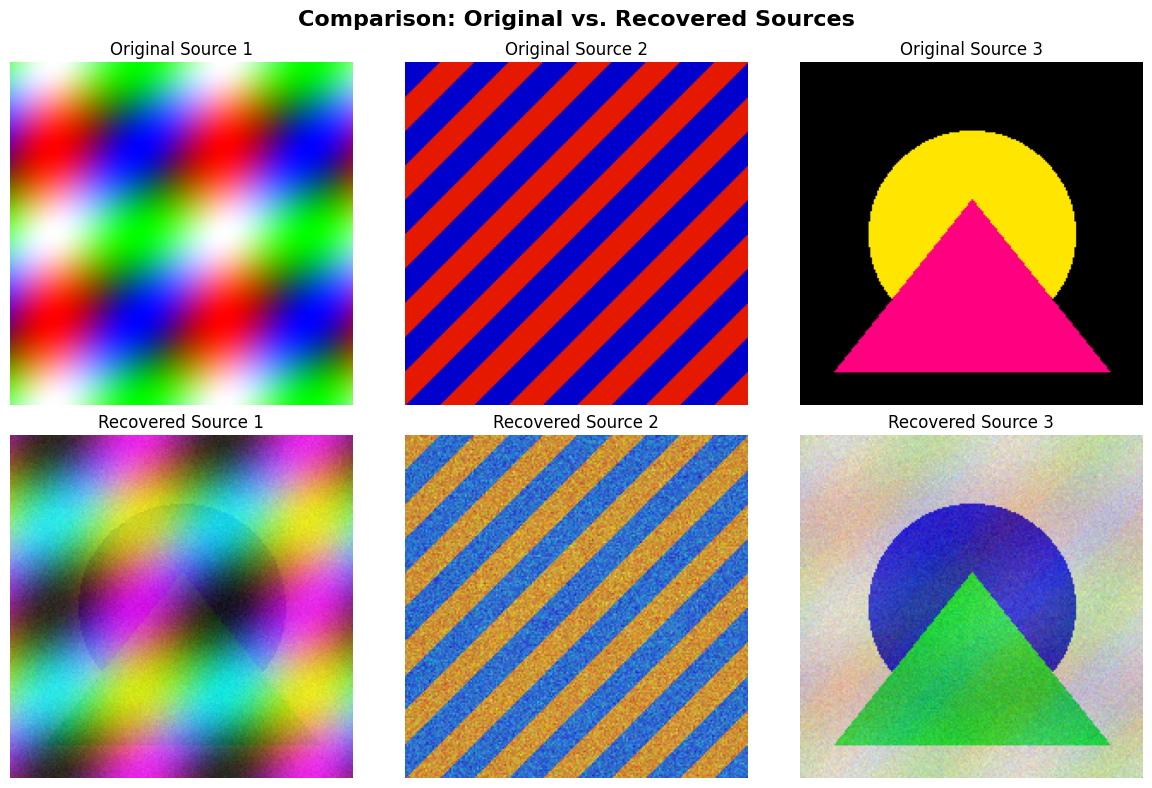

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for idx in range(3):
    axes[0, idx].imshow(sources[idx])
    axes[0, idx].set_title(f"Original Source {idx + 1}")
    axes[0, idx].axis("off")
    
    axes[1, idx].imshow(matched_reconstructed[idx])
    axes[1, idx].set_title(f"Recovered Source {idx + 1}")
    axes[1, idx].axis("off")

plt.suptitle("Comparison: Original vs. Recovered Sources", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

🎉 **Congratulations!** As you can see, the FastICA algorithm successfully separated the source images even with noise added, showing that the mixed images created by `ImageMixer` form a perfect practical exercise for students.